In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
#                                          Collect and Clean ALL Data
print("PHASE 1: Collecting and Cleaning ALL Data")

import os
import pandas as pd
import cv2
import numpy as np
from pathlib import Path

# Step 1: Collect ALL image files
print("Step 1: Collecting ALL image files...")

all_image_files = []

# Main data directories
data_dirs = [
    '/kaggle/input/neu-surface-defect-database/NEU-DET/train/images',
    '/kaggle/input/neu-surface-defect-database/NEU-DET/validation/images', 
    '/kaggle/input/neu-surface-defect-database/NEU-DET/test/images'
]

for data_dir in data_dirs:
    if os.path.exists(data_dir):
        for root, dirs, files in os.walk(data_dir):
            for file in files:
                if file.endswith('.jpg'):
                    all_image_files.append(os.path.join(root, file))

print(f"Total images found: {len(all_image_files)}")

# Step 2: Clean and standardize ALL images
print("Step 2: Cleaning and standardizing ALL images...")

def clean_and_standardize_image(image_path, target_size=(200, 200)):
    """Clean and standardize a single image"""
    try:
        img = cv2.imread(image_path)
        if img is None:
            return None
        
        # Convert to RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Resize
        img_resized = cv2.resize(img, target_size)
        
        # Enhance contrast using CLAHE
        lab = cv2.cvtColor(img_resized, cv2.COLOR_RGB2LAB)
        lab[:,:,0] = cv2.createCLAHE(clipLimit=2.0).apply(lab[:,:,0])
        enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
        
        # Normalize
        normalized = enhanced.astype(np.float32) / 255.0
        
        return normalized
    except Exception as e:
        print(f"Error cleaning {image_path}: {e}")
        return None

def preprocess_all_images(image_files, output_dir, target_size=(200, 200)):
    """Preprocess all images and save them"""
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    
    processed_files = []
    for i, img_path in enumerate(image_files):
        if i % 100 == 0:  # Progress indicator
            print(f"Processing image {i}/{len(image_files)}")
            
        cleaned_img = clean_and_standardize_image(img_path, target_size)
        
        if cleaned_img is not None:
            filename = Path(img_path).name
            output_path = os.path.join(output_dir, filename)
            
            # Save image
            img_to_save = (cleaned_img * 255).astype(np.uint8)
            cv2.imwrite(output_path, cv2.cvtColor(img_to_save, cv2.COLOR_RGB2BGR))
            processed_files.append(output_path)
    
    return processed_files

# Clean all images
all_cleaned_files = preprocess_all_images(
    all_image_files,
    '/kaggle/working/cleaned_all_images'
)

print(f"Cleaned images: {len(all_cleaned_files)}")

# Step 3: Create labels for ALL images - modified version
print("Step 3: Creating labels for ALL images...")

# Smart label detection
def smart_label_extractor(file_path):
    """Extract defect type from filename"""
    filename = os.path.basename(file_path).lower()
    
    # First attempt: first two letters
    first_two = filename[:2]
    if first_two in ['cr', 'in', 'pa', 'pi', 'ro', 'sc']:
        return first_two
    
    # Second attempt: search full name
    if 'crazing' in filename:
        return 'cr'
    elif 'inclusion' in filename:
        return 'in'
    elif 'patches' in filename:
        return 'pa'
    elif 'pitted' in filename:
        return 'pi'
    elif 'rolled' in filename:
        return 'ro'
    elif 'scratches' in filename:
        return 'sc'
    else:
        return None

# Apply extraction
full_df = pd.DataFrame({'file': all_cleaned_files})
full_df['label_name'] = full_df['file'].map(smart_label_extractor)

# Verify results
print("Label distribution after smart extraction:")
label_distribution = full_df['label_name'].value_counts()
print(label_distribution)

# Handle unlabeled files
if full_df['label_name'].isnull().any():
    null_count = full_df['label_name'].isnull().sum()
    print(f"{null_count} files could not be labeled")
    
    # Show examples of problematic files
    problematic_files = full_df[full_df['label_name'].isnull()]['file'].head(3)
    print("Examples of problematic files:")
    for file in problematic_files:
        print(f"   {os.path.basename(file)}")

# Clean data and create mapping
full_df = full_df.dropna(subset=['label_name'])
unique_labels = sorted(full_df['label_name'].unique())

# Dynamically create mapping
label_name_to_label_id = {label: i for i, label in enumerate(unique_labels)}
full_df['label'] = full_df['label_name'].map(label_name_to_label_id)

print(f"Final labels: {unique_labels}")
print(f"Mapping: {label_name_to_label_id}")
print(f"Number of classes: {len(unique_labels)}")

# Save the full cleaned dataset info
full_df.to_csv('/kaggle/working/full_cleaned_dataset.csv', index=False)
print("Saved full dataset info to: /kaggle/working/full_cleaned_dataset.csv")

print("PHASE 1 COMPLETED! Data is cleaned and ready for splitting.")
print("Next: Run PHASE 2 to split the data and train the model.")


PHASE 1: Collecting and Cleaning ALL Data
Step 1: Collecting ALL image files...
Total images found: 1800
Step 2: Cleaning and standardizing ALL images...
Processing image 0/1800
Processing image 100/1800
Processing image 200/1800
Processing image 300/1800
Processing image 400/1800
Processing image 500/1800
Processing image 600/1800
Processing image 700/1800
Processing image 800/1800
Processing image 900/1800
Processing image 1000/1800
Processing image 1100/1800
Processing image 1200/1800
Processing image 1300/1800
Processing image 1400/1800
Processing image 1500/1800
Processing image 1600/1800
Processing image 1700/1800
Cleaned images: 1800
Step 3: Creating labels for ALL images...
Label distribution after smart extraction:
label_name
in    300
sc    300
pi    300
pa    300
cr    300
ro    300
Name: count, dtype: int64
Final labels: ['cr', 'in', 'pa', 'pi', 'ro', 'sc']
Mapping: {'cr': 0, 'in': 1, 'pa': 2, 'pi': 3, 'ro': 4, 'sc': 5}
Number of classes: 6
Saved full dataset info to: /kagg

PHASE 2.5A: SIMPLE CNN MODEL TRAINING


2026-02-24 19:26:17.760031: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771961178.005938      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771961178.077423      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771961178.676989      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771961178.677036      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771961178.677040      55 computation_placer.cc:177] computation placer alr

=== LOADING DATA ===
Total samples: 1800
Label distribution:
label_name
in    300
sc    300
pi    300
pa    300
cr    300
ro    300
Name: count, dtype: int64
Loading and validating images...
Successfully loaded: 1800/1800 images

=== SPLITTING DATA ===
Training set: 1440 samples (80.0%)
Validation set: 180 samples (10.0%)
Test set: 180 samples (10.0%)

CREATING SIMPLE CNN MODEL


I0000 00:00:1771961210.590231      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1771961210.593149      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Simple CNN architecture:


...

I0000 00:00:1771961217.432420     194 service.cc:152] XLA service 0x7fcc5000fb70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771961217.432483     194 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1771961217.432489     194 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1771961218.356943     194 cuda_dnn.cc:529] Loaded cuDNN version 91002


 2/90 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.0625 - loss: 2.9428      

I0000 00:00:1771961228.530648     194 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.4118 - loss: 1.9694
Epoch 1: val_accuracy improved from -inf to 0.16667, saving model to /kaggle/working/simple_cnn_best.keras
90/90 ━━━━━━━━━━━━━━━━━━━━ 34s 203ms/step - accuracy: 0.4128 - loss: 1.9657 - val_accuracy: 0.1667 - val_loss: 5.4280 - learning_rate: 1.0000e-04
Epoch 2/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.6097 - loss: 1.1236
Epoch 2: val_accuracy did not improve from 0.16667
90/90 ━━━━━━━━━━━━━━━━━━━━ 14s 151ms/step - accuracy: 0.6100 - loss: 1.1225 - val_accuracy: 0.1667 - val_loss: 10.5201 - learning_rate: 1.0000e-04
Epoch 3/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.6992 - loss: 0.8708
Epoch 3: val_accuracy did not improve from 0.16667
90/90 ━━━━━━━━━━━━━━━━━━━━ 13s 149ms/step - accuracy: 0.6991 - loss: 0.8713 - val_accuracy: 0.1667 - val_loss: 10.2116 - learning_rate: 1.0000e-04
Epoch 4/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.7457 - loss: 0.8223
Epoch 4: val_accur

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


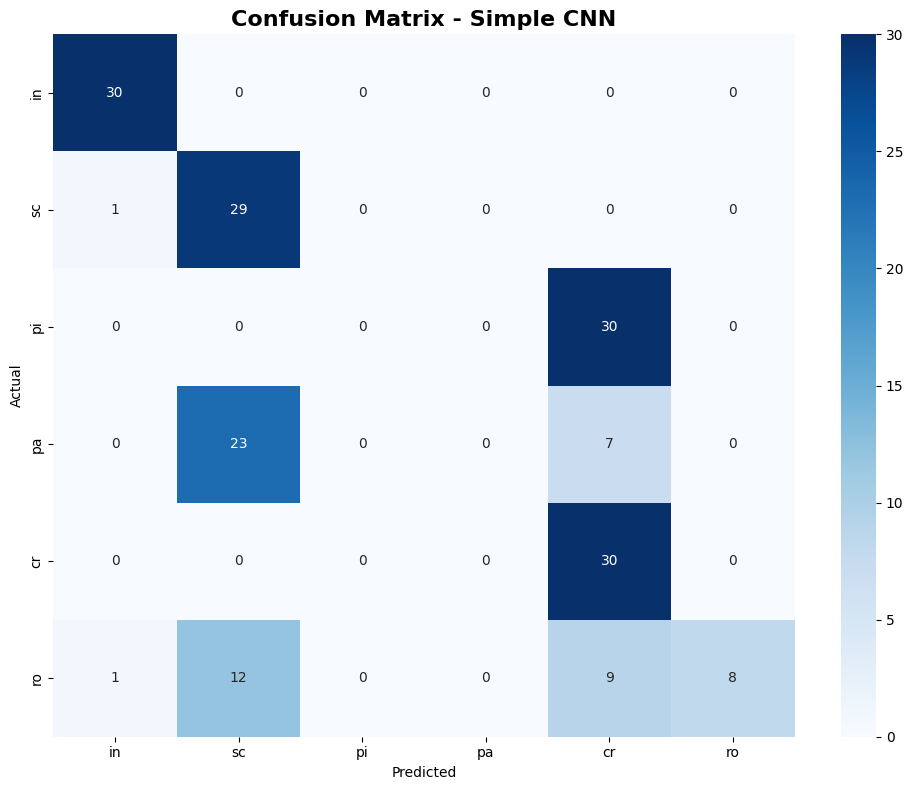

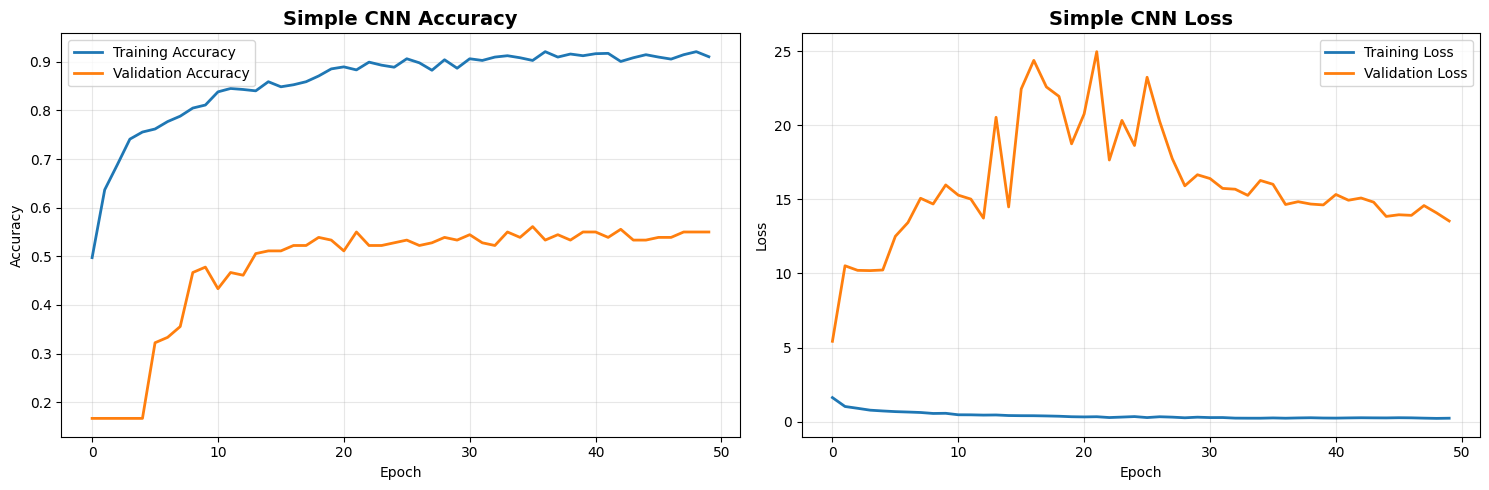


SIMPLE CNN SUMMARY
Final Test Accuracy: 0.5389
Model saved: /kaggle/working/simple_cnn_best.keras
Visualizations saved:
- simple_cnn_confusion_matrix.png
- simple_cnn_training_history.png


In [2]:
                                               #  CNN MODEL
print("PHASE 2.5A: SIMPLE CNN MODEL TRAINING")
print("="*60)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import cv2
import os
from pathlib import Path

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Load data
print("=== LOADING DATA ===")
full_df = pd.read_csv('/kaggle/working/full_cleaned_dataset.csv')
print(f"Total samples: {len(full_df)}")

print("Label distribution:")
label_counts = full_df['label_name'].value_counts()
print(label_counts)

# Load images function
def load_images_optimized(df):
    images = []
    labels = []
    valid_files = []
    
    print("Loading and validating images...")
    for idx, row in df.iterrows():
        try:
            img = cv2.imread(row['file'])
            if img is None:
                continue
                
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (200, 200))
            img = img.astype(np.float32) / 255.0
            
            if np.isnan(img).any() or np.isinf(img).any():
                continue
                
            images.append(img)
            labels.append(row['label'])
            valid_files.append(row['file'])
            
        except Exception as e:
            continue
    
    print(f"Successfully loaded: {len(images)}/{len(df)} images")
    return np.array(images), np.array(labels), valid_files

# Load data
X, y, valid_files = load_images_optimized(full_df)

# Split data
print("\n=== SPLITTING DATA ===")
# 80% training, 10% validation, 10% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.111, random_state=42, stratify=y_temp
)

print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)") 
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

# Create Simple CNN model
print("\n" + "="*50)
print("CREATING SIMPLE CNN MODEL")
print("="*50)

def create_simple_cnn(input_shape=(200, 200, 3), num_classes=6):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        
        # First convolutional block
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Second convolutional block
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Third convolutional block
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Fourth convolutional block
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Dense layers
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

num_classes = len(np.unique(y))
simple_model = create_simple_cnn(input_shape=(200, 200, 3), num_classes=num_classes)

simple_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Simple CNN architecture:")
simple_model.summary()

# Data augmentation
datagen = keras.preprocessing.image.ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=False,
    zoom_range=0.1,
    fill_mode='nearest'
)

# Callbacks
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-7,
    verbose=1
)

checkpoint = keras.callbacks.ModelCheckpoint(
    '/kaggle/working/simple_cnn_best.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Train Simple CNN
print("\n" + "="*50)
print("TRAINING SIMPLE CNN MODEL")
print("="*50)

history = simple_model.fit(
    datagen.flow(X_train, y_train, batch_size=16),
    steps_per_epoch=len(X_train) // 16,
    epochs=50,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, reduce_lr, checkpoint],
    verbose=1
)

# Load best model
best_model = keras.models.load_model('/kaggle/working/simple_cnn_best.keras')

# Evaluate on test set
print("\n" + "="*50)
print("EVALUATING SIMPLE CNN MODEL")
print("="*50)

test_loss, test_accuracy = best_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Predictions
y_pred = best_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

class_names = list(full_df['label_name'].unique())

print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes, target_names=class_names))

# Create confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Simple CNN', fontsize=16, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('/kaggle/working/simple_cnn_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
ax1.set_title('Simple CNN Accuracy', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss plot
ax2.plot(history.history['loss'], label='Training Loss', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
ax2.set_title('Simple CNN Loss', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/simple_cnn_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("SIMPLE CNN SUMMARY")
print("="*60)
print(f"Final Test Accuracy: {test_accuracy:.4f}")
print(f"Model saved: /kaggle/working/simple_cnn_best.keras")
print(f"Visualizations saved:")
print("- simple_cnn_confusion_matrix.png")
print("- simple_cnn_training_history.png")
print("="*60)